# The Drivers of Well-Being: An Explainable AI Approach to OECD Socioeconomics
**Author:** Amro Askar | **Program:** DATA SCIENCE, University of Milano-Bicocca

### Environment Setup
We initialize the environment by importing the necessary data manipulation, statistical, and Machine Learning libraries. We rely heavily on `scikit-learn` for algorithmic selection and `statsmodels` for temporal inference.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### Data Ingestion & Pivoting
The raw OECD dataset (`data_all.csv`) contains thousands of rows across various demographic splits. We filter strictly for the general population ('Total') to maintain a macro-economic perspective and pivot the dataset into a standard Country-Year cross-sectional panel.

In [2]:
df_raw = pd.read_csv('data_all.csv')

# Filter for general population to avoid demographic duplication
df_filtered = df_raw[(df_raw['Sex'] == 'Total') &
                     (df_raw['Age'] == 'Total') &
                     (df_raw['Education level'] == 'Total')]

print(f"Raw Dataset Shape: {df_filtered.shape}")

# Pivot to Wide Format
df_wide = df_filtered.pivot_table(
    index=['Reference area', 'TIME_PERIOD'],
    columns='Measure',
    values='OBS_VALUE'
).reset_index()

# After transforming into wide formate the dataset
# It contains 46 countries * 6 years measuring 62 measures + Country + Year
print(f"Wide Dataset Shape: {df_wide.shape}")

df_wide.columns.name = None
df_wide = df_wide.rename(columns={'Reference area': 'Country', 'TIME_PERIOD': 'Year'})

target = 'Life satisfaction'
# Drop rows where the target itself is missing (cannot train on missing labels)
df_wide = df_wide.dropna(subset=[target]).copy()

print(f"Starting Dataset Shape: {df_wide.shape}")

Raw Dataset Shape: (6973, 30)
Wide Dataset Shape: (276, 64)
Starting Dataset Shape: (153, 64)


### Automated Cleaning (Sparsity, Target Leakage & KNN Imputation)
To preserve our limited sample size, we avoid Listwise Deletion.
1. **Sparsity Filter:** We drop any column missing >20% of its data.
2. **Preventing Target Leakage:** We programmatically drop columns related to subjective mood (e.g., "affect balance"). This prevents the AI from "cheating" by predicting happiness using other happiness proxies, forcing it to find objective socioeconomic drivers.
3. **KNN Imputation:** For the remaining gaps, we utilize K-Nearest Neighbors ($k=5$) to mathematically impute missing values based on the profiles of similar nations.

In [3]:
# 1. Sparsity Filter
threshold = 0.20
missing_fractions = df_wide.isnull().mean()
missing_fractions

Country                                           0.000000
Year                                              0.000000
Adult literacy skills                             0.862745
Adult numeracy skills                             0.862745
Adults with low numeracy skills                   0.843137
                                                    ...   
Top satisfaction with time use quintile           0.797386
Top science scores decile                         0.803922
Top wealthiest households decile                  0.895425
Voter turnout                                     0.699346
Youth not in employment, education or training    0.202614
Length: 64, dtype: float64

In [4]:
cols_to_keep = missing_fractions[missing_fractions <= threshold].index
df_reduced = df_wide[cols_to_keep].copy()
cols_to_keep

Index(['Country', 'Year', 'Difficulty making ends meet', 'Employment rate',
       'Feeling safe at night', 'Feelings of physical pain',
       'Housing affordability', 'Inability to keep home adequately warm',
       'Lack of social support', 'Life satisfaction',
       'Life satisfaction score less than 5', 'Long hours in paid work',
       'Long-term unemployment rate', 'Negative affect balance',
       'Not feeling safe at night', 'Social support',
       'Top earnings of full-time employees decile',
       'Top life satisfaction scores quintile'],
      dtype='object')

In [5]:
# 2. Remove Target Leakers
# Our goal is to predict a "target" variable (in our project, this is "Life satisfaction").
# Target Leakage happens when you accidentally leave a column in your dataset that is essentially a proxy or a duplicate of the thing you are trying to predict
leakers = ['satisfaction', 'affect balance']
non_numeric = ['Country', 'Year']
# Keep this column ONLY if it is not a Country/Year,
# AND it does not contain the word 'satisfaction' or 'affect balance' in its name.
features = [c for c in df_reduced.columns if c not in non_numeric and not any(l in c.lower() for l in leakers)]

# 3. KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_reduced[features] = imputer.fit_transform(df_reduced[features])

print(f"Features surviving Sparsity & Leaker Removal: {len(features)}")

Features surviving Sparsity & Leaker Removal: 12


In [6]:
df_reduced[features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 6 to 266
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Difficulty making ends meet                 153 non-null    float64
 1   Employment rate                             153 non-null    float64
 2   Feeling safe at night                       153 non-null    float64
 3   Feelings of physical pain                   153 non-null    float64
 4   Housing affordability                       153 non-null    float64
 5   Inability to keep home adequately warm      153 non-null    float64
 6   Lack of social support                      153 non-null    float64
 7   Long hours in paid work                     153 non-null    float64
 8   Long-term unemployment rate                 153 non-null    float64
 9   Not feeling safe at night                   153 non-null    float64
 10  Social support     

### The Correlation Filter
The OECD provides multiple redundant metrics (e.g., various definitions of wealth). To prevent multicollinearity from confusing the algorithms, we scan a correlation matrix and automatically drop any variable with a Pearson correlation greater than 0.85.

['Not feeling safe at night', 'Social support']
Features dropped due to high redundancy (>0.85): 2
Final features passed to the Draft AI: 10


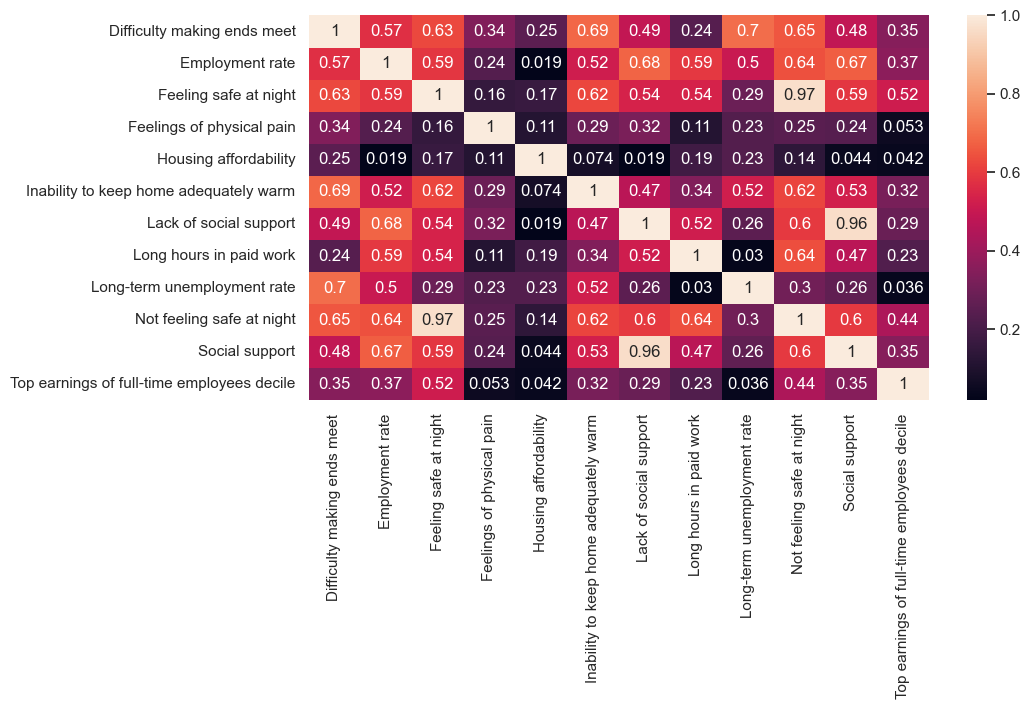

In [7]:
corr_matrix = df_reduced[features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.85)]
features_filtered = [f for f in features if f not in to_drop_corr]

plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True)

print(to_drop_corr)

print(f"Features dropped due to high redundancy (>0.85): {len(to_drop_corr)}")
print(f"Final features passed to the Draft AI: {len(features_filtered)}")

### Algorithmic Feature Selection (Draft Random Forest)
Rather than manually selecting variables, we train a "Draft" Random Forest Regressor on the surviving features. The algorithm ranks the variables by their true mathematical impact on global happiness, effectively extracting the "Golden Predictors" without human bias.

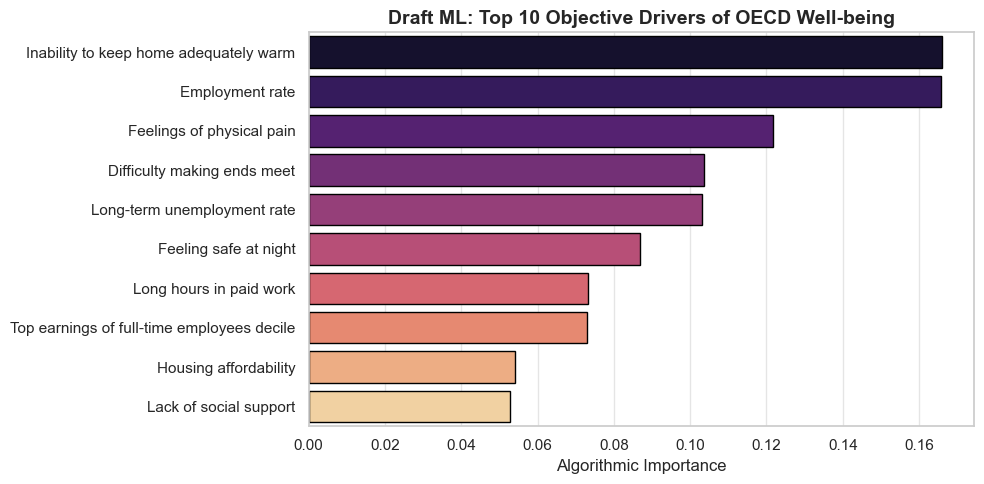

In [8]:
X_draft = df_reduced[features_filtered]
y_draft = df_reduced[target]

scaler_draft = StandardScaler()
X_scaled_draft = pd.DataFrame(scaler_draft.fit_transform(X_draft), columns=X_draft.columns)

rf_draft = RandomForestRegressor(n_estimators=100, random_state=42)
rf_draft.fit(X_scaled_draft, y_draft)

importances = rf_draft.feature_importances_
imp_df = pd.DataFrame({'Feature': X_draft.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
top_4_features = imp_df.head(4)['Feature'].tolist()

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=imp_df.head(10), palette='magma', edgecolor='black')
plt.title('Draft ML: Top 10 Objective Drivers of OECD Well-being', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Isolating the Golden Dataset
We extract the Top 4 features identified by the AI to serve as our finalized predictors for the remainder of the analysis.

In [9]:
final_columns = ['Country', 'Year', target] + top_4_features
df_final = df_reduced[final_columns].copy()
print(f"Golden Dataset Created. Shape: {df_final.shape}")
df_final.head()

Golden Dataset Created. Shape: (153, 7)


,Country,Year,Life satisfaction,Inability to keep home adequately warm,Employment rate,Feelings of physical pain,Difficulty making ends meet
6,Australia,2020,7.200000,7.08,76.129,26.541096,20.2
13,Austria,2021,7.991946,1.70,76.428,23.619403,10.1
14,Austria,2022,7.882644,2.70,78.006,23.619403,11.9
15,Austria,2023,7.696147,3.90,77.920,29.874415,13.6
16,Austria,2024,7.622019,4.00,78.197,29.874415,13.1


### VIF Check
Before executing temporal linear regressions, we must guarantee our top predictors do not violate OLS assumptions. A Variance Inflation Factor (VIF) below 5 confirms that the Random Forest selected a statistically safe, non-collinear subset of variables.

In [10]:
X_vif = sm.add_constant(df_final[top_4_features])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("VARIANCE INFLATION FACTOR (VIF)")
print(vif_data[vif_data['Feature'] != 'const'].to_string(index=False))

VARIANCE INFLATION FACTOR (VIF)
                               Feature      VIF
Inability to keep home adequately warm 1.993797
                       Employment rate 1.560272
             Feelings of physical pain 1.137638
           Difficulty making ends meet 2.225675


### Data Integrity: Imputation Safety Check
To prove that our KNN Imputation did not destroy or heavily skew the original variance of the data, we overlay the distribution of the original raw data (pre-imputation) with our final imputed dataset.

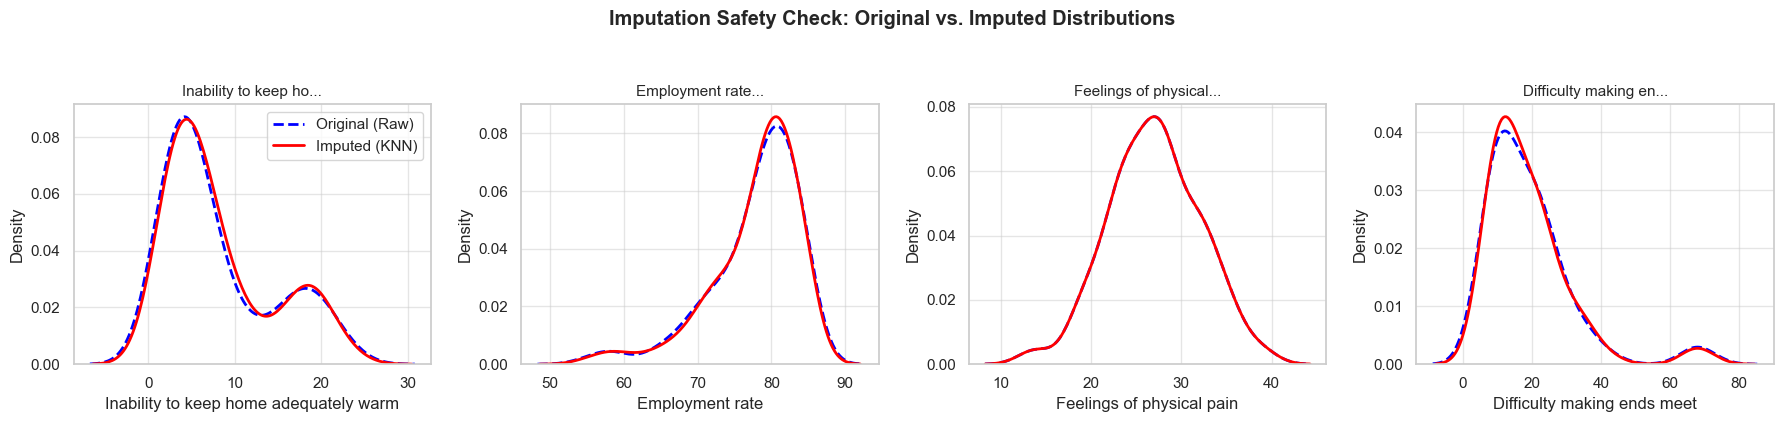

In [11]:
df_original_raw = df_wide[['Country', 'Year'] + top_4_features].copy()

fig, axes = plt.subplots(1, len(top_4_features), figsize=(18, 4))

for i, col in enumerate(top_4_features):
    sns.kdeplot(df_original_raw[col].dropna(), ax=axes[i], color='blue', linestyle='--', linewidth=2, label='Original (Raw)')
    sns.kdeplot(df_final[col], ax=axes[i], color='red', linewidth=2, label='Imputed (KNN)')
    axes[i].set_title(f'{col[:20]}...', fontsize=11)
    if i == 0:
        axes[i].legend()

plt.suptitle('Imputation Safety Check: Original vs. Imputed Distributions', y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

### Targeted EDA: Univariate Distributions
Having verified data integrity, we perform targeted Exploratory Data Analysis on our algorithmically selected predictors to understand the socioeconomic baseline of the OECD.

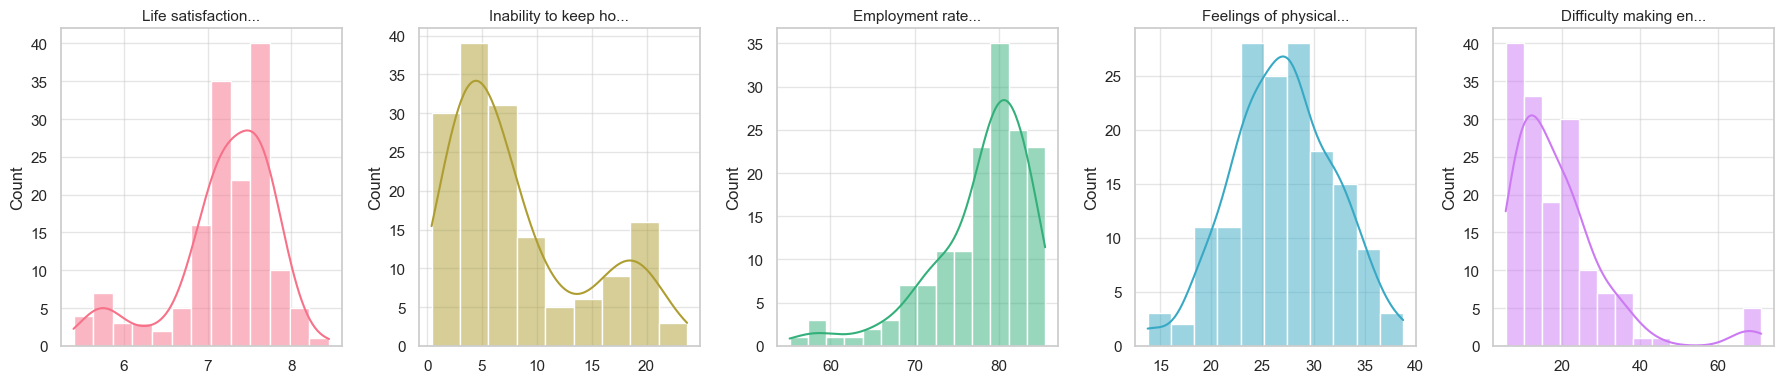

In [12]:
fig, axes = plt.subplots(1, len(top_4_features)+1, figsize=(18, 4))
cols_to_plot = [target] + top_4_features

for i, col in enumerate(cols_to_plot):
    sns.histplot(df_final[col], kde=True, ax=axes[i], color=sns.color_palette("husl", len(cols_to_plot))[i])
    axes[i].set_title(f'{col[:20]}...', fontsize=11)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

### Targeted EDA: Outlier Detection
We utilize boxplots to identify extreme macroeconomic anomalies across the OECD panel.

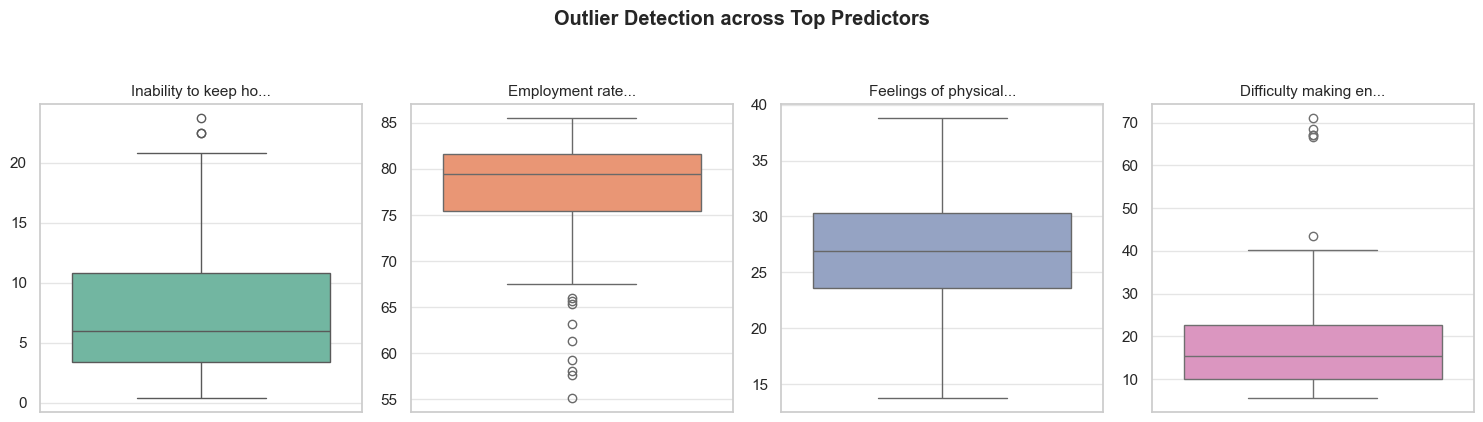

In [13]:
fig, axes = plt.subplots(1, len(top_4_features), figsize=(15, 4))
for i, col in enumerate(top_4_features):
    sns.boxplot(y=df_final[col], ax=axes[i], color=sns.color_palette("Set2")[i])
    axes[i].set_title(f'{col[:20]}...', fontsize=11)
    axes[i].set_ylabel('')
plt.suptitle('Outlier Detection across Top Predictors', y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

### Targeted EDA: Bivariate Relationships
We map the selected predictors directly against our target variable (Life Satisfaction) to visually confirm the logic captured by the Random Forest.

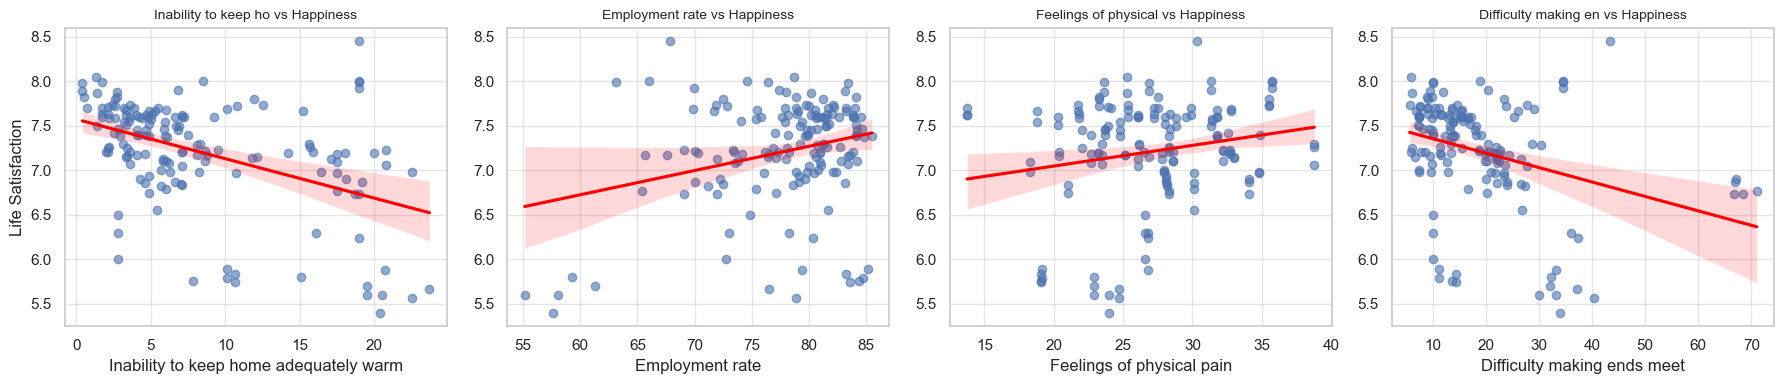

In [14]:
fig, axes = plt.subplots(1, len(top_4_features), figsize=(18, 4))
for i, col in enumerate(top_4_features):
    sns.regplot(x=col, y=target, data=df_final, ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    axes[i].set_title(f'{col[:20]} vs Happiness', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Life Satisfaction' if i==0 else '')
plt.tight_layout()
plt.show()

# The Global Macroeconomic Model (Results)

In [15]:
# Clean column names for statsmodels syntax (replace spaces/hyphens with underscores)
rf_data = df_final.copy()
df_final.columns = df_final.columns.str.replace(' ', '_').str.replace('-', '_')
top_4_clean = [col.replace(' ', '_').replace('-', '_') for col in top_4_features]

# Build the protected econometric formula
econometric_formula = f"""
    Life_satisfaction ~
    {top_4_clean[0]} +
    {top_4_clean[1]} +
    {top_4_clean[2]} + I({top_4_clean[2]} ** 2) +
    {top_4_clean[3]} + I({top_4_clean[3]} ** 2)
"""

# Fit with HC3 Robust Standard Errors
primary_model = smf.ols(formula=econometric_formula, data=df_final).fit(cov_type='HC3')

print("=== GLOBAL MACROECONOMIC MODEL (BASELINE) ===")
print(primary_model.summary())

=== GLOBAL MACROECONOMIC MODEL (BASELINE) ===
                            OLS Regression Results                            
Dep. Variable:      Life_satisfaction   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     9.737
Date:                Sat, 30 May 2026   Prob (F-statistic):           5.18e-09
Time:                        13:39:59   Log-Likelihood:                -101.77
No. Observations:                 153   AIC:                             217.5
Df Residuals:                     146   BIC:                             238.8
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

# Final Predictive Model Optimization (GridSearchCV)
To prevent the "Curse of Dimensionality" on our small dataset ($N \approx 153$), we discard the noisy variables and retrain a final Random Forest strictly on the Top 4 features. To mathematically justify our hyperparameter choices and prevent overfitting, we deploy `GridSearchCV` with 5-fold cross-validation to find the optimally regularized model.

Initiating Grid Search for Hyperparameter Tuning...

--- ALGORITHMIC TUNING RESULTS ---
Optimal Parameters Found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Final Tuned ML R-Squared: 0.521
Final Tuned ML RMSE:      0.372



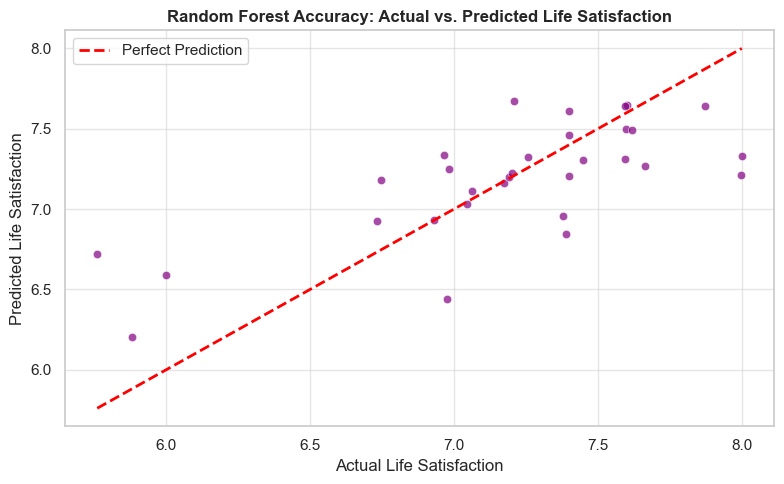

In [16]:
X_final = rf_data[top_4_features]
y_final = rf_data[target]

scaler_final = StandardScaler()
X_scaled_final = pd.DataFrame(scaler_final.fit_transform(X_final), columns=X_final.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_final, y_final, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Initiating Grid Search for Hyperparameter Tuning...\n")

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
rf_final = grid_search.best_estimator_

print("--- ALGORITHMIC TUNING RESULTS ---")
print(f"Optimal Parameters Found: {grid_search.best_params_}\n")

y_pred = rf_final.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Final Tuned ML R-Squared: {r2:.3f}")
print(f"Final Tuned ML RMSE:      {rmse:.3f}\n")

# 6. Visualize the ML Predictions vs. Reality
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='purple', alpha=0.7, ax=ax)

# Draw the perfect prediction diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

ax.set_title('Random Forest Accuracy: Actual vs. Predicted Life Satisfaction', fontweight='bold')
ax.set_xlabel('Actual Life Satisfaction')
ax.set_ylabel('Predicted Life Satisfaction')
ax.legend()
plt.tight_layout()
plt.show()

# Validation & Explainable AI (XAI)
We conclude by defending the algorithm's validity. We use 5-Fold Cross-Validation to prove the model is mathematically stable on a small sample size. Finally, we generate SHAP (SHapley Additive exPlanations) values to visually prove the *directionality* of our predictors, elevating the model from a "black box" to Explainable AI.

5-Fold CV Mean R-Squared: -1.117 (+/- 1.452)



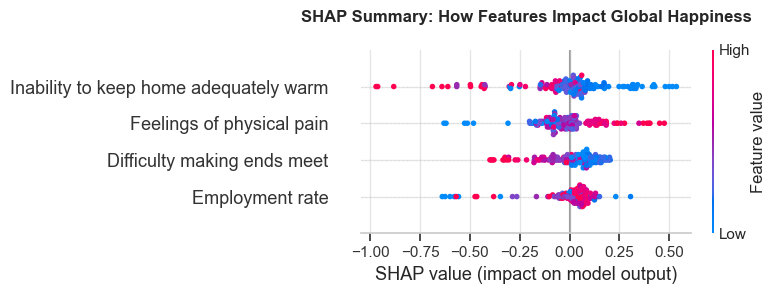

In [17]:
# 1. 5-Fold Cross Validation
cv_scores = cross_val_score(rf_final, X_scaled_final, y_final, cv=5, scoring='r2')
print(f"5-Fold CV Mean R-Squared: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})\n")

# 2. SHAP Values
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_scaled_final)

plt.figure(figsize=(9, 6))
plt.title("SHAP Summary: How Features Impact Global Happiness", fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_scaled_final, show=False)
plt.tight_layout()
plt.show()

# The Temporal Shift - Segmented Models

In [18]:
# Segment the data by the newly renamed 'Year' column
df_2021 = df_final[df_final['Year'] == 2021]
df_2023 = df_final[df_final['Year'] == 2023]

# Run the exact same formula on 2021
model_2021 = smf.ols(formula=econometric_formula, data=df_2021).fit(cov_type='HC3')
print("\n=== 2021 MODEL (CRISIS) ===")
print(model_2021.summary())

# Run the exact same formula on 2023
model_2023 = smf.ols(formula=econometric_formula, data=df_2023).fit(cov_type='HC3')
print("\n=== 2023 MODEL (RECOVERY) ===")
print(model_2023.summary())


=== 2021 MODEL (CRISIS) ===
                            OLS Regression Results                            
Dep. Variable:      Life_satisfaction   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                    0.8136
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.568
Time:                        13:41:11   Log-Likelihood:                -29.328
No. Observations:                  35   AIC:                             72.66
Df Residuals:                      28   BIC:                             83.54
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

# The Pooled Interaction Model (Significance Check)

=== POOLED INTERACTION MODEL (STATISTICAL SIGNIFICANCE) ===
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                         -0.1390      0.312     -0.445      0.656      -0.751       0.473
Inability_to_keep_home_adequately_warm            -0.4383      0.392     -1.118      0.264      -1.207       0.330
is_2023                                           -0.0007      0.312     -0.002      0.998      -0.612       0.611
Inability_to_keep_home_adequately_warm:is_2023    -0.2223      0.477     -0.466      0.642      -1.158       0.714
Employment_rate                                    0.0147      0.539      0.027      0.978      -1.042       1.071
Employment_rate:is_2023                            0.0865      0.623      0.139      0.890      -1.135       1.308
Feelings_of_physical

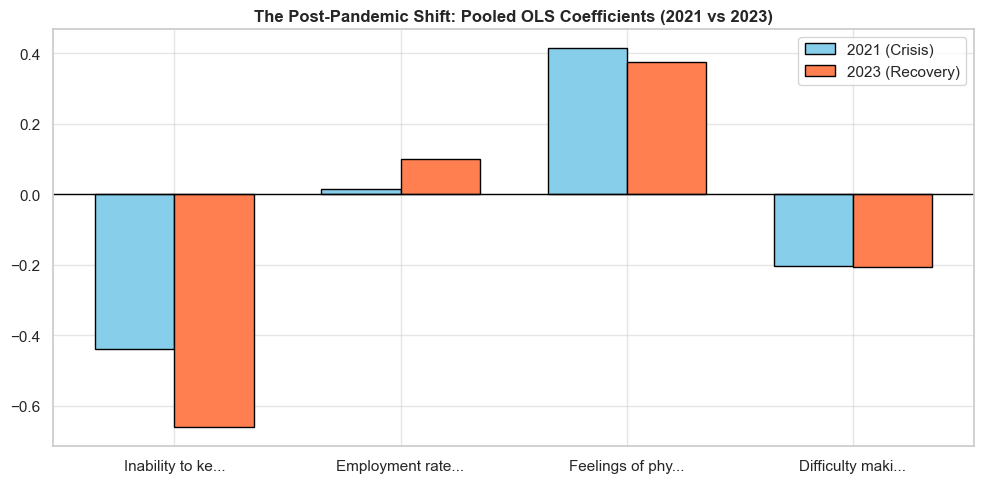

In [19]:
# 1. Prepare the Pooled Dataset using 'Year'
df_pooled = df_final[df_final['Year'].isin([2021, 2023])].copy()

# 2. Standardize so the visualization Betas are comparable
scaler_ols = StandardScaler()
df_pooled[top_4_clean] = scaler_ols.fit_transform(df_pooled[top_4_clean])
df_pooled['Life_satisfaction'] = scaler_ols.fit_transform(df_pooled[['Life_satisfaction']])

# 3. Create the Time Dummy
df_pooled['is_2023'] = (df_pooled['Year'] == 2023).astype(int)

# 4. Build the Baseline Interaction Formula
interaction_terms = [f"{feat} * is_2023" for feat in top_4_clean]
formula_interact = "Life_satisfaction ~ " + " + ".join(interaction_terms)

# Add the polynomial terms for deprivation to keep it mathematically sound
for feat in top_4_clean:
    if 'warm' in feat.lower() or 'ends_meet' in feat.lower():
        formula_interact += f" + I({feat} ** 2)"

# 5. Fit the Interaction Model
interaction_model = smf.ols(formula=formula_interact, data=df_pooled).fit(cov_type='HC3')

print("=== POOLED INTERACTION MODEL (STATISTICAL SIGNIFICANCE) ===")
print(interaction_model.summary().tables[1])

# 6. Extract and Plot the Baseline vs. Shift
results = []
for feat in top_4_clean:
    baseline = interaction_model.params[feat]
    shift = interaction_model.params[f"{feat}:is_2023"]
    new_total = baseline + shift

    # Clean the name for the chart display
    display_name = feat.replace('_', ' ')
    results.append({'Feature': display_name, '2021 Impact': baseline, '2023 Impact': new_total})

pivot_coef = pd.DataFrame(results).set_index('Feature')

# Visualize the Shift
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
x = np.arange(len(pivot_coef.index))
ax.bar(x - width/2, pivot_coef['2021 Impact'], width, label='2021 (Crisis)', color='skyblue', edgecolor='black')
ax.bar(x + width/2, pivot_coef['2023 Impact'], width, label='2023 (Recovery)', color='coral', edgecolor='black')

ax.set_title('The Post-Pandemic Shift: Pooled OLS Coefficients (2021 vs 2023)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f[:15]+'...' for f in pivot_coef.index])
ax.legend()
ax.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()